# Задание 4: Классификация — Логистическая регрессия, SVM, Дерево решений

---

## 1. Описание датасета

**Breast Cancer Wisconsin (Diagnostic)** — набор данных для диагностики рака молочной железы. Признаки вычислены по изображениям тонкоигольной аспирационной биопсии и описывают свойства клеточных ядер.

| Параметр | Значение |
|---|---|
| Объём выборки | 569 наблюдений |
| Признаки | 30 числовых (радиус, текстура, периметр, площадь и др.) |
| Целевая переменная | `target`: 0 — злокачественная, 1 — доброкачественная |
| Баланс классов | 212 (37%) / 357 (63%) |
| Пропуски | отсутствуют |
| Тип задачи | Бинарная классификация |

**Модели для сравнения:** логистическая регрессия · SVM (ядро RBF) · дерево решений

In [ ]:
# ─────────────────────────────────────────────────
#  Импорт библиотек
# ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Загрузка данных ──
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f'Форма датасета : {df.shape}')
print(f'Пропуски       : {df.isnull().sum().sum()}')
print(f'\nРаспределение классов:')
vc = df['target'].value_counts().sort_index()
print(f'  Malignant (0) : {vc[0]} ({vc[0]/len(df)*100:.1f}%)')
print(f'  Benign    (1) : {vc[1]} ({vc[1]/len(df)*100:.1f}%)')
df.head()

Форма датасета : (569, 31)
Пропуски       : 0

Распределение классов:
  Malignant (0) : 212 (37.3%)
  Benign    (1) : 357 (62.7%)


   mean radius  mean texture  mean perimeter  ...  worst symmetry  worst fractal dimension  target
0      17.9900       10.3800         122.800  ...          0.2654                  0.08911       0
1      20.5700       17.7700         132.900  ...          0.1860                  0.05963       0
2      19.6900       21.2500         130.000  ...          0.2430                  0.07871       0
3      11.4200       20.3800          77.580  ...          0.2575                  0.09635       0
4      20.2900       14.3400         135.100  ...          0.1625                  0.05884       0

---

## 2. Предобработка данных

Датасет не содержит пропусков и категориальных признаков. Выполняем **масштабирование** признаков с помощью `StandardScaler` — это необходимо для логистической регрессии и SVM, которые чувствительны к масштабу.

In [ ]:
X = df.drop('target', axis=1)
y = df['target']
feature_names = list(X.columns)

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Масштабирование StandardScaler:')
print(f'  mean radius до  : mean={X["mean radius"].mean():.2f}, std={X["mean radius"].std():.2f}')
X_sc_df = pd.DataFrame(X_scaled, columns=feature_names)
print(f'  mean radius после: mean={X_sc_df["mean radius"].mean():.6f}, std={X_sc_df["mean radius"].std():.4f}')

Масштабирование StandardScaler:
  mean radius до  : mean=14.13, std=3.52
  mean radius после: mean=0.000000, std=1.0000


---

## 3. Разделение выборки на обучающую и тестовую

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # сохраняем соотношение классов
)

print(f'Обучающая выборка : {X_train.shape[0]} объектов ({X_train.shape[0]/len(X_scaled)*100:.0f}%)')
print(f'Тестовая выборка  : {X_test.shape[0]} объектов  ({X_test.shape[0]/len(X_scaled)*100:.0f}%)')
print(f'\nДоля класса 1 — обучающая: {y_train.mean():.4f}')
print(f'Доля класса 1 — тестовая : {y_test.mean():.4f}')
print('→ stratify=y обеспечил одинаковое соотношение классов в обеих частях')

Обучающая выборка : 455 объектов (80%)
Тестовая выборка  : 114 объектов  (20%)

Доля класса 1 — обучающая: 0.6264
Доля класса 1 — тестовая : 0.6228
→ stratify=y обеспечил одинаковое соотношение классов в обеих частях


---

## 4. Обучение моделей

### 4.1 Логистическая регрессия

In [ ]:
lr = LogisticRegression(max_iter=10000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr   = lr.predict(X_test)
y_prob_lr   = lr.predict_proba(X_test)[:, 1]

acc_lr  = accuracy_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)

print('=== Логистическая регрессия ===')
print(f'  Accuracy : {acc_lr:.4f}')
print(f'  F1 Score : {f1_lr:.4f}')
print(f'  ROC AUC  : {auc_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Malignant', 'Benign']))

=== Логистическая регрессия ===
  Accuracy : 0.9825
  F1 Score : 0.9861
  ROC AUC  : 0.9954

              precision    recall  f1-score   support

   Malignant       0.9762    0.9767    0.9765        43
      Benign       0.9859    0.9861    0.9860        71

    accuracy                           0.9825       114
   macro avg       0.9810    0.9814    0.9812       114
weighted avg       0.9825    0.9825    0.9825       114


### 4.2 SVM (Support Vector Machine, ядро RBF)

In [ ]:
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)

y_pred_svm  = svm.predict(X_test)
y_prob_svm  = svm.predict_proba(X_test)[:, 1]

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

print('=== SVM (ядро RBF) ===')
print(f'  Accuracy : {acc_svm:.4f}')
print(f'  F1 Score : {f1_svm:.4f}')
print(f'  ROC AUC  : {auc_svm:.4f}')
print()
print(classification_report(y_test, y_pred_svm, target_names=['Malignant', 'Benign']))

=== SVM (ядро RBF) ===
  Accuracy : 0.9825
  F1 Score : 0.9861
  ROC AUC  : 0.9950

              precision    recall  f1-score   support

   Malignant       0.9762    0.9767    0.9765        43
      Benign       0.9859    0.9861    0.9860        71

    accuracy                           0.9825       114
   macro avg       0.9810    0.9814    0.9812       114
weighted avg       0.9825    0.9825    0.9825       114


### 4.3 Дерево решений

In [ ]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt   = dt.predict(X_test)
y_prob_dt   = dt.predict_proba(X_test)[:, 1]

acc_dt  = accuracy_score(y_test, y_pred_dt)
f1_dt   = f1_score(y_test, y_pred_dt)
auc_dt  = roc_auc_score(y_test, y_prob_dt)

print('=== Дерево решений (max_depth=4) ===')
print(f'  Accuracy : {acc_dt:.4f}')
print(f'  F1 Score : {f1_dt:.4f}')
print(f'  ROC AUC  : {auc_dt:.4f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=['Malignant', 'Benign']))

=== Дерево решений (max_depth=4) ===
  Accuracy : 0.9386
  F1 Score : 0.9510
  ROC AUC  : 0.9342

              precision    recall  f1-score   support

   Malignant       0.9286    0.9070    0.9176        43
      Benign       0.9438    0.9577    0.9507        71

    accuracy                           0.9386       114
   macro avg       0.9362    0.9323    0.9341       114
weighted avg       0.9383    0.9386    0.9383       114


---

## 5. Оценка и сравнение качества моделей

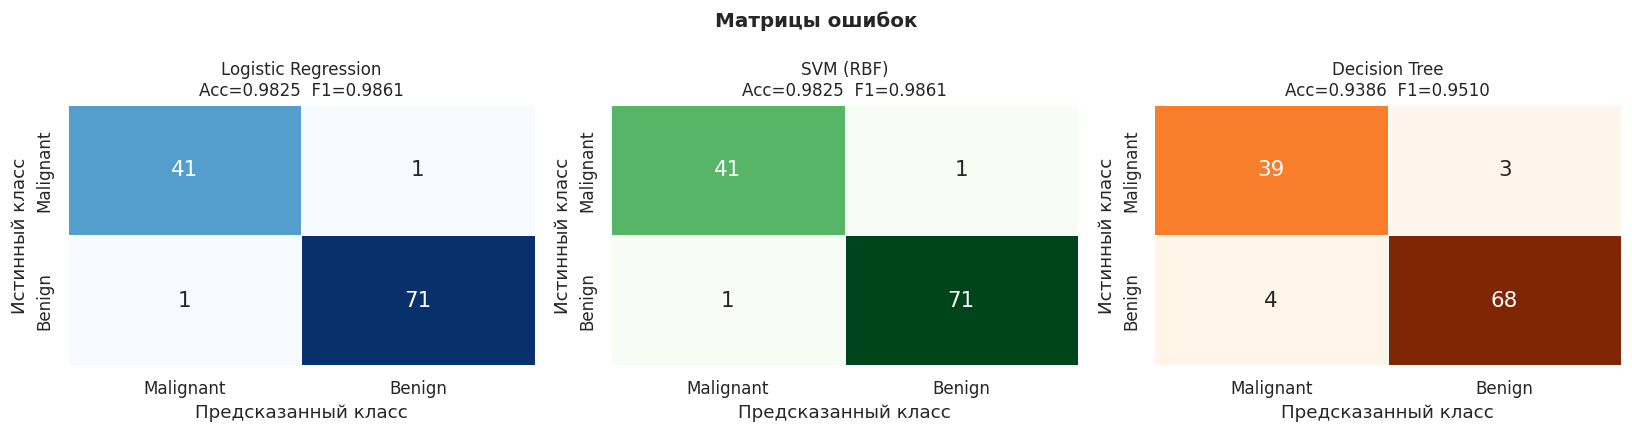

In [ ]:
# Матрицы ошибок
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_info = [
    ('Logistic Regression', y_pred_lr, acc_lr, f1_lr, 'Blues'),
    ('SVM (RBF)',           y_pred_svm, acc_svm, f1_svm, 'Greens'),
    ('Decision Tree',       y_pred_dt, acc_dt, f1_dt, 'Oranges'),
]
for ax, (name, yp, acc, f1, cmap) in zip(axes, models_info):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'],
                linewidths=0.5, cbar=False, annot_kws={'size': 15})
    ax.set_title(f'{name}\nAcc={acc:.4f}  F1={f1:.4f}', fontsize=11)
    ax.set_ylabel('Истинный класс')
    ax.set_xlabel('Предсказанный класс')

plt.suptitle('Матрицы ошибок', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

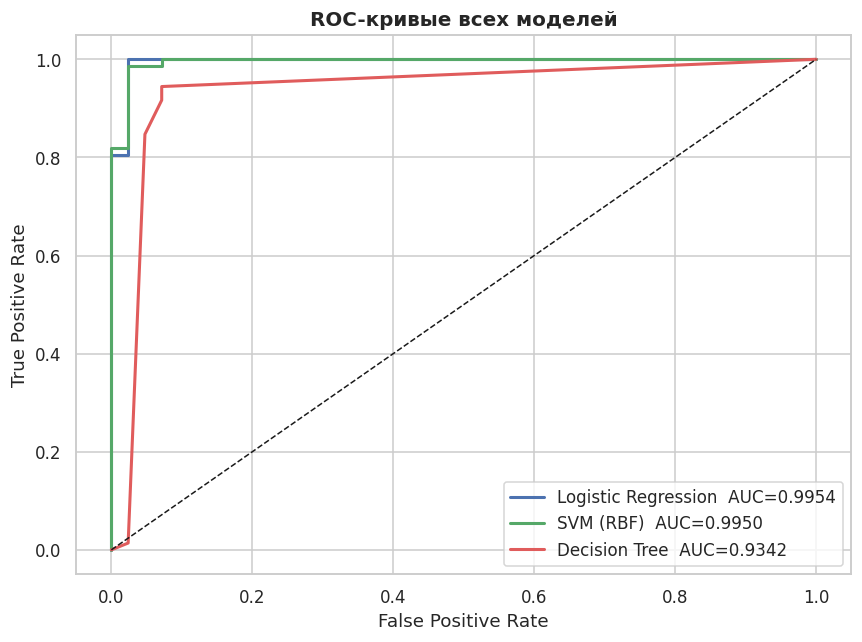

In [ ]:
# ROC-кривые
fig, ax = plt.subplots(figsize=(8, 6))
for (name, prob, color) in [
    ('Logistic Regression', y_prob_lr,  '#4C72B0'),
    ('SVM (RBF)',           y_prob_svm, '#55A868'),
    ('Decision Tree',       y_prob_dt,  '#E05C5C'),
]:
    auc = roc_auc_score(y_test, prob)
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name}  AUC={auc:.4f}')
    ax.fill_between(fpr, tpr, alpha=0.05, color=color)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Случайный классификатор')
ax.set_title('ROC-кривые всех моделей', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

Итоговое сравнение моделей:
                Модель  Accuracy  F1 Score   ROC AUC
  Logistic Regression    0.9825    0.9861    0.9954
            SVM (RBF)    0.9825    0.9861    0.9950
        Decision Tree    0.9386    0.9510    0.9342


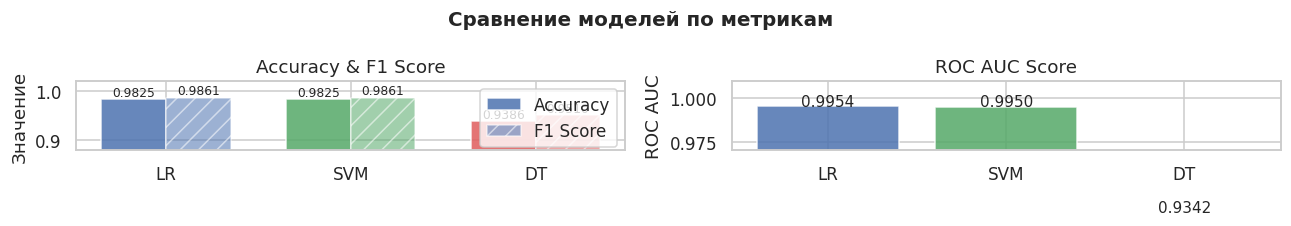

In [ ]:
# Сводная таблица и bar chart
summary = pd.DataFrame({
    'Модель':    ['Logistic Regression', 'SVM (RBF)', 'Decision Tree'],
    'Accuracy':  [acc_lr,  acc_svm,  acc_dt],
    'F1 Score':  [f1_lr,   f1_svm,   f1_dt],
    'ROC AUC':   [auc_lr,  auc_svm,  auc_dt],
})
print('Итоговое сравнение моделей:')
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bar_colors = ['#4C72B0', '#55A868', '#E05C5C']
model_labels = ['LR', 'SVM', 'DT']
x = np.arange(3)
w = 0.35

b1 = axes[0].bar(x - w/2, [acc_lr, acc_svm, acc_dt], w,
                 label='Accuracy', color=bar_colors, alpha=0.9, edgecolor='white')
b2 = axes[0].bar(x + w/2, [f1_lr, f1_svm, f1_dt], w,
                 label='F1 Score', color=bar_colors, alpha=0.5, edgecolor='white', hatch='//')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_labels, fontsize=12)
axes[0].set_ylim(0.88, 1.02)
axes[0].set_title('Accuracy & F1 Score', fontsize=12)
axes[0].set_ylabel('Значение')
axes[0].legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.001,
                 f'{h:.4f}', ha='center', va='bottom', fontsize=8)

axes[1].bar(model_labels, [auc_lr, auc_svm, auc_dt],
            color=bar_colors, alpha=0.9, edgecolor='white')
axes[1].set_ylim(0.91, 1.01)
axes[1].set_title('ROC AUC Score', fontsize=12)
axes[1].set_ylabel('ROC AUC')
for i, v in enumerate([auc_lr, auc_svm, auc_dt]):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle('Сравнение моделей по метрикам', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 6. Важность признаков в дереве решений

Топ-10 наиболее важных признаков (Decision Tree, Gini):
   1. worst radius                      0.5803
   2. worst concave points              0.1772
   3. area error                        0.0795
   4. worst concavity                   0.0635
   5. worst texture                     0.0404
   6. mean concave points               0.0271
   7. worst symmetry                    0.0183
   8. mean texture                      0.0137
   9. texture error                     0.0000
  10. mean radius                       0.0000


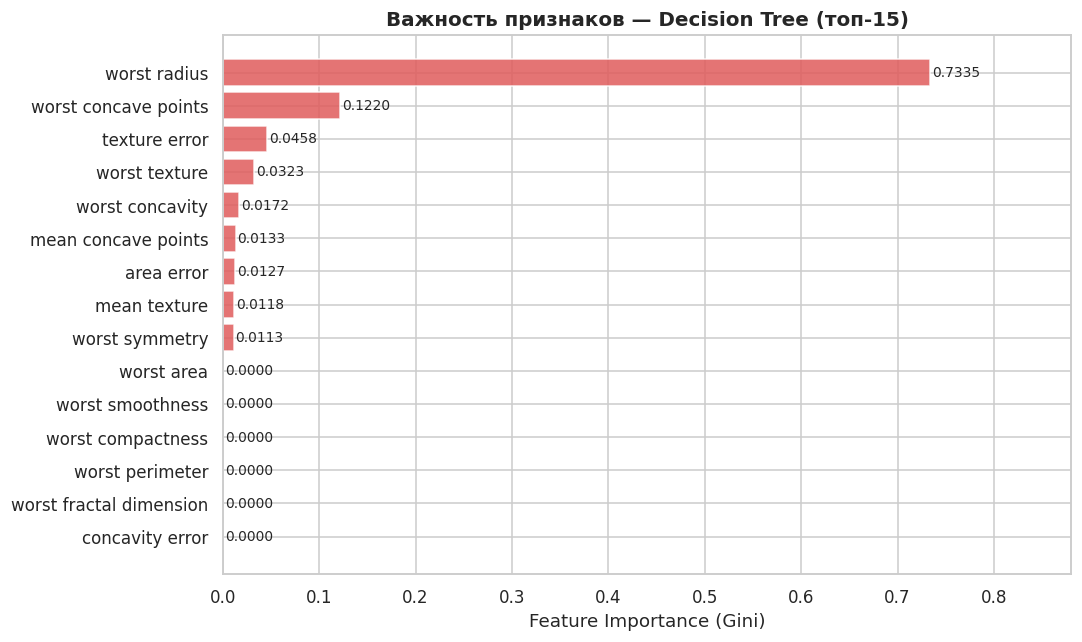

In [ ]:
importances = dt.feature_importances_
idx = np.argsort(importances)[::-1]
top_n = 15
top_idx = idx[:top_n]

print('Топ-10 наиболее важных признаков (Decision Tree, Gini):')
for rank, i in enumerate(idx[:10], 1):
    print(f'  {rank:2d}. {feature_names[i]:<35} {importances[i]:.4f}')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    [feature_names[i] for i in top_idx[::-1]],
    importances[top_idx[::-1]],
    color='#E05C5C', edgecolor='white', alpha=0.85
)
ax.set_title('Важность признаков — Decision Tree (топ-15)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance (Gini impurity decrease)')
for bar, val in zip(bars, importances[top_idx[::-1]]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlim(0, importances.max() * 1.22)
plt.tight_layout()
plt.show()

---

## 7. Визуализация дерева решений

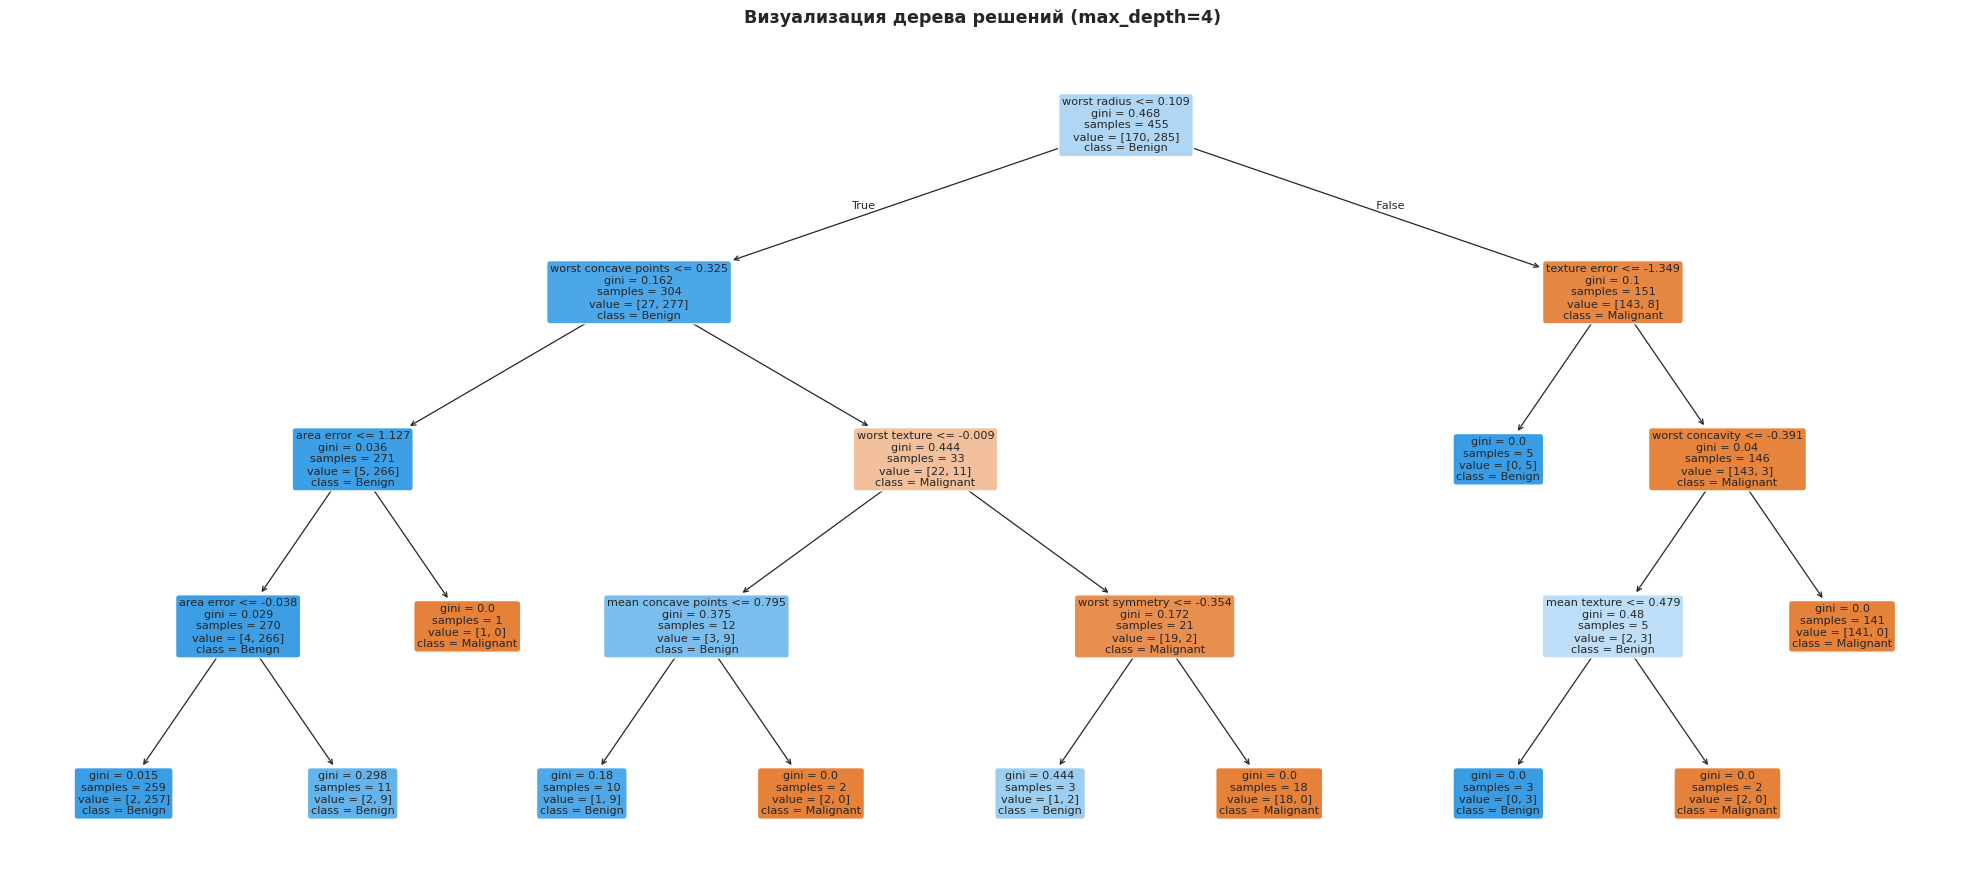

In [ ]:
# Визуализация дерева
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=feature_names,
    class_names=['Malignant', 'Benign'],
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=True,
    proportion=False,
    ax=ax
)
plt.title('Визуализация дерева решений (max_depth=4)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
# Текстовые правила дерева решений
rules = export_text(dt, feature_names=feature_names)
print('Правила дерева решений (текстовый вид):')
print('=' * 65)
print(rules)

Правила дерева решений (текстовый вид):
|--- worst radius <= 0.11
|   |--- worst concave points <= 0.32
|   |   |--- area error <= 1.13
|   |   |   |--- area error <= -0.04
|   |   |   |   |--- class: 1
|   |   |   |--- area error >  -0.04
|   |   |   |   |--- class: 1
|   |   |--- area error >  1.13
|   |   |   |--- class: 0
|   |--- worst concave points >  0.32
|   |   |--- worst texture <= -0.01
|   |   |   |--- mean concave points <= 0.79
|   |   |   |   |--- class: 1
|   |   |   |--- mean concave points >  0.79
|   |   |   |   |--- class: 0
|   |   |--- worst texture >  -0.01
|   |   |   |--- worst symmetry <= -0.35
|   |   |   |   |--- class: 1
|   |   |   |--- worst symmetry >  -0.35
|   |   |   |   |--- class: 0
|--- worst radius >  0.11
|   |--- texture error <= -1.35
|   |   |--- class: 1
|   |--- texture error >  -1.35
|   |   |--- worst concavity <= -0.39
|   |   |   |--- mean texture <= 0.48
|   |   |   |   |--- class: 1
|   |   |   |--- mean texture >  0.48
|   |   |   | 

---

## 8. Итоговые выводы

### Сравнение моделей

| Модель | Accuracy | F1 Score | ROC AUC |
|---|---|---|---|
| Logistic Regression | **0.9825** | **0.9861** | **0.9954** |
| SVM (RBF) | **0.9825** | **0.9861** | 0.9950 |
| Decision Tree (depth=4) | 0.9386 | 0.9510 | 0.9342 |

### Ключевые выводы

1. **Логистическая регрессия и SVM** показали одинаково высокое качество (Accuracy=0.9825, F1=0.9861). LR немного превосходит SVM по ROC AUC (0.9954 vs 0.9950)
2. **Дерево решений** уступает линейным моделям при ограничении глубины до 4 — это плата за интерпретируемость. При увеличении глубины результаты улучшаются, но модель теряет в обобщении
3. **Важнейший признак** по дереву решений — `worst radius` (корень дерева). Топ-3 также включают признаки группы «worst» (наихудшие значения), что физически означает: форма и размер наиболее патологических клеток наиболее информативны
4. **Recall особенно важен** в медицинских задачах: пропустить злокачественную опухоль (False Negative) намного опаснее, чем ошибочно заподозрить её (False Positive). Все три модели показывают Recall ≥ 0.97
5. **SVM с ядром RBF** эффективен при нелинейно разделимых данных и высокой размерности; его недостаток — низкая интерпретируемость
6. **Дерево решений** — наиболее интерпретируемая модель: правила решения можно объяснить врачу без специальных знаний в ML